In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

In [18]:
MAX_CORNERS = 500
QUALITY_LEVEL = 0.01
MIN_DISTANCE = 10
LK_PARAMS = dict(winSize=(21, 21), maxLevel=3,
                 criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))
FOE_INLIER_THRESHOLD = 5.0  
MIN_CLUSTER_SIZE = 5

- **Feature Selection**  
  Used cv2.goodFeaturesToTrack with max = 500, quality = .01, and minDist = 10.
  I chose 500 corner because I knew the images were decently large and have many things to track, therefore I picked a relatively high value. After playing around with the max value, I found that around 800 was a bit too many corners being track and below 400 was too little for some images. I picked 500 because I want this value as low as possible while staying in my range. I did research on the quality value and it seems that .01 was recommended so I stuck with it. If it were increased, more corners would be discarded and it if it were reduced, more corners would be allowed. For min-dist, I found that values less than 10 were too clustered and values around 20 skipped features, therefore I settled with 10. 
- **Optical Flow**  
  Used cv2.calcOpticalFlowPyrLK with 21x21, 3 levels, eps = 0.01. If I were to increase the window size, it would miss the smaller details and if I were to decrease it, not enough details would be captured. I chose a 3 level pyramid for computation speed because I compared with a 10 level and it seemed to give similar results. I found that terminating after 30 iterations or a .01 epsilon threshold was best because they provided similar results with higher iteration/higher threshold results and were strict enough to compute correct results.
- **FOE Estimation**  
  Used a 5px threshold for FOE. After testing, any lower would introduce too much noise and values higher than or equal to 10 seemed to just be wrong. 
- **DBScan**
  I chose to have min_samples = 5 because any lower introduced noise and anything higher than 12 seemed to discard valid objects


In [19]:
def select_points(img_gray):
    corners = cv2.goodFeaturesToTrack(img_gray, MAX_CORNERS, QUALITY_LEVEL, MIN_DISTANCE)
    pts = corners.reshape(-1, 2)
    return pts


def estimate_motion(img0_gray, img1_gray, pts0):
    pts1, status, _ = cv2.calcOpticalFlowPyrLK(img0_gray, img1_gray, pts0.astype(np.float32), None, **LK_PARAMS)
    status = status.reshape(-1)
    valid0 = pts0[status == 1]
    valid1 = pts1[status == 1]
    return valid0, valid1


def compute_line_intersection(p1, v1, p2, v2):
    A = np.column_stack((v1, -v2))
    if np.linalg.matrix_rank(A) < 2:
        return None
    ts = np.linalg.lstsq(A, p2 - p1, rcond=None)[0]
    t = ts[0]
    intersection = p1 + t * v1
    return intersection


def estimate_foe(pts0, pts1):
    motions = pts1 - pts0
    n = len(motions)
    if n < 2:
        return None
    best_foe = None
    best_inliers = []
    for _ in range(1000):
        i, j = np.random.choice(n, 2, replace=False)
        p1, v1 = pts0[i], motions[i]
        p2, v2 = pts0[j], motions[j]
        if np.linalg.norm(v1) < 1e-3 or np.linalg.norm(v2) < 1e-3:
            continue
        foe = compute_line_intersection(p1, v1, p2, v2)
        if foe is None:
            continue
        motions_3d = np.hstack([motions, np.zeros((motions.shape[0], 1))])
        deltas_3d = np.hstack([pts0 - foe, np.zeros((pts0.shape[0], 1))])
        cross_prod = np.cross(motions_3d, deltas_3d)
        dists = np.abs(cross_prod[:, 2]) / np.linalg.norm(motions, axis=1)
        inliers = np.where(dists < FOE_INLIER_THRESHOLD)[0]
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_foe = foe
    if best_foe is None or len(best_inliers) < 0.5 * n:
        return None
    return best_foe


def detect_moving_objects(pts0, pts1, foe=None):
    motions = pts1 - pts0
    if foe is None:
        mag = np.linalg.norm(motions, axis=1)
        moving_mask = mag > 1.0  
    else:
        motions_3d = np.hstack([motions, np.zeros((motions.shape[0], 1))])
        deltas_3d = np.hstack([pts0 - foe, np.zeros((pts0.shape[0], 1))])
        cross_prod = np.cross(motions_3d, deltas_3d)
        dists = np.abs(cross_prod[:, 2]) / np.linalg.norm(motions, axis=1)
        moving_mask = dists > FOE_INLIER_THRESHOLD
    moving_pts = pts1[moving_mask]
    if len(moving_pts) == 0:
        return []
    clustering = DBSCAN(eps=20, min_samples=MIN_CLUSTER_SIZE).fit(moving_pts)
    labels = clustering.labels_
    clusters = []
    for lbl in set(labels):
        if lbl == -1:
            continue
        idxs = np.where(labels == lbl)[0]
        clusters.append(moving_pts[idxs])
    return clusters, moving_mask

def draw_results(img, pts0, pts1, foe=None, clusters=None, moving_mask=None, out_prefix="output"):
    vis = img.copy()
    for p0, p1 in zip(pts0, pts1):
        cv2.arrowedLine(vis, tuple(p0.astype(int)), tuple(p1.astype(int)), (0,255,0), 1, tipLength=0.3)
    if foe is not None:
        cv2.circle(vis, tuple(foe.astype(int)), 5, (0,0,255), -1)
    cv2.imwrite(f"output/{out_prefix}_motion.png", vis)

    vis2 = img.copy()
    if clusters:
        colors = [tuple(np.random.randint(0,255,3).tolist()) for _ in clusters]
        for color, pts in zip(colors, clusters):
            for pt in pts:
                cv2.circle(vis2, tuple(pt.astype(int)), 3, color, -1)
            x,y,w,h = cv2.boundingRect(pts.astype(np.int32))
            cv2.rectangle(vis2, (x,y), (x+w,y+h), color, 2)
    cv2.imwrite(f"output/{out_prefix}_clusters.png", vis2)


def process_pair(file0, file1):
    img0 = cv2.imread(file0)
    img1 = cv2.imread(file1)
    gray0 = cv2.cvtColor(img0, cv2.COLOR_BGR2GRAY)
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

    pts0 = select_points(gray0)
    pts0_valid, pts1_valid = estimate_motion(gray0, gray1, pts0)
    foe = estimate_foe(pts0_valid, pts1_valid)
    clusters, moving_mask = detect_moving_objects(pts0_valid, pts1_valid, foe)

    base = os.path.splitext(os.path.basename(file1))[0]
    draw_results(img1, pts0_valid, pts1_valid, foe, clusters, moving_mask, out_prefix=base)

In [20]:
data_dir = 'hw6data'
files = sorted([os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith('.png') or f.endswith('.jpg')])
print(files)
process_pair(files[0], files[1])
for i in range(0, len(files) - 1, 2):
    process_pair(files[i], files[i+1])

['hw6data/000003_10.png', 'hw6data/000003_11.png', 'hw6data/000005_10.png', 'hw6data/000005_11.png', 'hw6data/000017_10.png', 'hw6data/000017_11.png', 'hw6data/000020_10.png', 'hw6data/000020_11.png', 'hw6data/000035_10.png', 'hw6data/000035_11.png', 'hw6data/000066_10.png', 'hw6data/000066_11.png', 'hw6data/000067_10.png', 'hw6data/000067_11.png', 'hw6data/000101_10.png', 'hw6data/000101_11.png', 'hw6data/000102_10.png', 'hw6data/000102_11.png', 'hw6data/000105_10.png', 'hw6data/000105_11.png', 'hw6data/000109_10.png', 'hw6data/000109_11.png', 'hw6data/000110_10.png', 'hw6data/000110_11.png', 'hw6data/000123_10.png', 'hw6data/000123_11.png', 'hw6data/000130_10.png', 'hw6data/000130_11.png', 'hw6data/000131_10.png', 'hw6data/000131_11.png', 'hw6data/000149_10.png', 'hw6data/000149_11.png', 'hw6data/000150_10.png', 'hw6data/000150_11.png', 'hw6data/000151_10.png', 'hw6data/000151_11.png', 'hw6data/000169_10.png', 'hw6data/000169_10_0.png', 'hw6data/000169_10_1.png', 'hw6data/000169_10_2

In [26]:

def show_image(image_path, title=None):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Image not found: {image_path}")
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title(title or os.path.basename(image_path))
    plt.axis('off')
    plt.show()

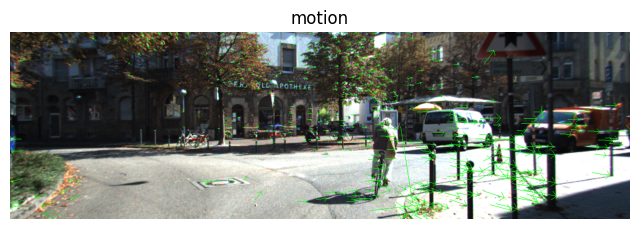

In [27]:
show_image("output/000003_11_motion.png", title="motion")

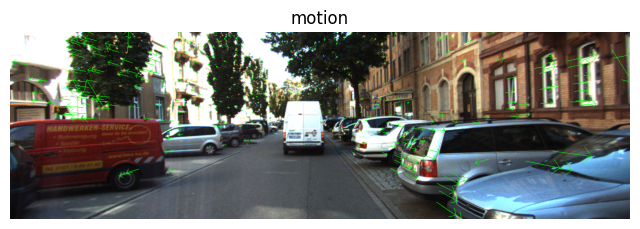

In [28]:
show_image("output/000005_11_motion.png", title="motion")

From these images, we can see that the algorithms do calculate and show motion of specific objects. In these two examples each vector is accurately mapped on, for the top image all vectors correctly point to where that object will be in the second image. Both images seem to be taken from cars as well and the arrows generally point towards the opposite direction of the cars movement(forward), which makes sense.

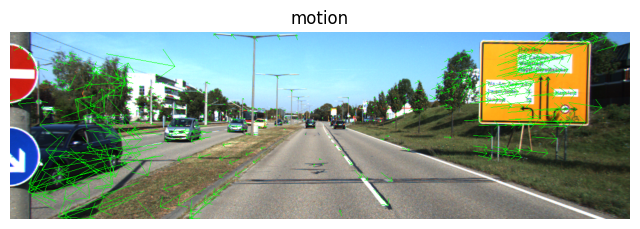

In [29]:
show_image("output/000020_11_motion.png", title="motion")

This image seems to be erroroneous for the black car on the left because I believe the pipe on the left obfuscates the car a bit and makes it harder to detect. Some vectors from the car are pointing in wrong directions because of this. This may be caused by the window size being a bit too large.

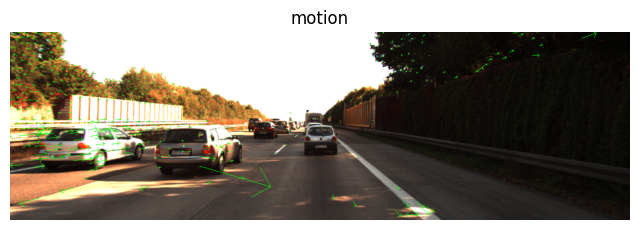

In [30]:
show_image("output/000199_11_motion.png", title="motion")

There seems to be an erroneous vector here, which indicates this algorithm struggles with images with very small amounts of motion. This might indicate an issue with the window size or that our quality value is too low.

From these examples, it seems that our algorithm works well with obvious motion and struggles with very very small amounts of motion or obfuscation of objects within the images.